# Sales Forecasting & Exploratory Data Analysis

**Goal:** Understand the business drivers behind `Revenue` and `COGS`, then prepare a reliable seasonal baseline for the 2023-01-01 to 2024-07-01 forecast horizon.

**Notebook flow:**
1. Load and validate the source tables.
2. Explore revenue, COGS, gross margin, and seasonality.
3. Segment customers with RFM to identify value concentration.
4. Measure cohort retention to evaluate repeat-purchase behavior.
5. Estimate promotion impact on revenue, repeat behavior, and margin.
6. Prepare sales features and YoY growth inputs for forecasting.

**Key business read:** Historical revenue is meaningful but uneven. Growth is not only a forecasting problem; it is also shaped by customer retention, promotion profitability, and seasonal demand patterns.


## 1. Imports, Config & Reusable Chart Style

This section sets up the notebook environment and defines a shared chart style. Reusing the same helper functions keeps all charts visually consistent: same colors, grid style, label sizes, number formatting, and annotation behavior.


In [237]:
import sys
print(sys.executable)

c:\Users\reust\OneDrive\datathon-vinuni\.venv\Scripts\python.exe


In [238]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\reust\OneDrive\datathon-vinuni
['.git', '.gitignore', '.venv', 'baseline.ipynb', 'customers.csv', 'datathon-2026-F.E.N.S', 'EDA version 2 - backup before codex edits.ipynb', 'EDA version 2.ipynb', 'geography.csv', 'inventory.csv', 'New folder', 'orders.csv', 'order_items.csv', 'payments.csv', 'products.csv', 'promotions.csv', 'returns.csv', 'reviews.csv', 'sales.csv', 'sample_submission.csv', 'shipments.csv', 'Thanh-Part 1+EDA.ipynb', 'web_traffic.csv']


In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter
import warnings

warnings.filterwarnings('ignore')

DATA_DIR = 'dataset/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
OUT_FILE = DATA_DIR + 'submission.csv'


In [240]:
# --- Shared chart style snippet: use this for every chart in the notebook ---
sns.set_theme(style="whitegrid", context="notebook")

CHART_COLORS = {
    "revenue": "#2563EB",
    "cogs": "#F97316",
    "margin": "#16A34A",
    "promo": "#DC2626",
    "no_promo": "#0F766E",
    "neutral": "#64748B",
}

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def money_billions(x, pos=None):
    return f"{x / 1e9:.1f}B"

def money_millions(x, pos=None):
    return f"{x / 1e6:.0f}M"

def style_axis(ax, title, xlabel=None, ylabel=None, y_format=None):
    # Apply a common visual treatment to one matplotlib axis.
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35)
    ax.grid(axis="x", visible=False)
    if y_format == "billions":
        ax.yaxis.set_major_formatter(FuncFormatter(money_billions))
    elif y_format == "millions":
        ax.yaxis.set_major_formatter(FuncFormatter(money_millions))
    elif y_format == "percent":
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    return ax

def annotate_bars(ax, fmt="{:.1%}", dy=0.01):
    # Add value labels above bars with a consistent font style.
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + dy,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )
    return ax


In [241]:
import pandas as pd

df = pd.read_csv("customers.csv")
df.head()

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search


## 2. Load & Inspect Data

The goal here is to confirm table availability, date coverage, schema consistency, missing values, duplicates, and basic revenue/COGS ranges before drawing business conclusions.


In [242]:
sub = pd.read_csv("sample_submission.csv")
sub.head()

,Date,Revenue,COGS
0,1/1/2023,2665507.20,2518885.15
1,1/2/2023,1280007.89,1136463.00
2,1/3/2023,1015899.51,822721.12
3,1/4/2023,1142997.27,914554.18
4,1/5/2023,1236312.34,984390.24


In [243]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
payments = pd.read_csv("payments.csv")
products = pd.read_csv("products.csv")
sales =pd.read_csv('sales.csv')
geography =pd.read_csv('geography.csv')
returns =pd.read_csv('returns.csv')
inventory=pd.read_csv('inventory.csv')

**Data Assumption - Order Status**

Customer behavior analysis should use completed transactions. Cancelled or unfinished orders do not represent confirmed purchases and can overstate frequency, retention, and monetary value.


In [244]:
# Valid completed orders for customer behavior analysis.
orders["order_date"] = pd.to_datetime(orders["order_date"])

order_status_summary = orders["order_status"].value_counts(dropna=False).rename_axis("order_status").reset_index(name="orders")
order_status_summary["share"] = order_status_summary["orders"] / order_status_summary["orders"].sum()

valid_orders = orders[orders["order_status"] == "delivered"].copy()
returned_orders = orders[orders["order_status"] == "returned"].copy()
invalid_or_open_orders = orders[~orders["order_status"].isin(["delivered", "returned"])].copy()

order_status_summary


,order_status,orders,share
0,delivered,516716,0.798702
1,cancelled,59462,0.091912
2,returned,36142,0.055866
3,shipped,13773,0.021289
4,paid,13577,0.020986
5,created,7275,0.011245


**Insight - order status filter:** RFM, cohort, repeat purchase, and promotion/customer value metrics should use `valid_orders`, defined as orders with `order_status == "delivered"`. Returned orders can be analyzed separately as a satisfaction or post-purchase issue, while cancelled, created, paid, and shipped orders should not be counted as completed customer behavior.


In [245]:
customers.info()
orders.info()
order_items.info()
payments.info()
products.info()
sales.info()
geography.info()


<class 'pandas.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   customer_id          121930 non-null  int64
 1   zip                  121930 non-null  int64
 2   city                 121930 non-null  str  
 3   signup_date          121930 non-null  str  
 4   gender               121930 non-null  str  
 5   age_group            121930 non-null  str  
 6   acquisition_channel  121930 non-null  str  
dtypes: int64(2), str(5)
memory usage: 6.5 MB
<class 'pandas.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        646945 non-null  int64         
 1   order_date      646945 non-null  datetime64[us]
 2   customer_id     646945 non-null  int64         
 3   zip             646945 non-null  int64       

In [246]:
sales.info()
sales.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3833 non-null   str    
 1   Revenue  3833 non-null   float64
 2   COGS     3833 non-null   float64
dtypes: float64(2), str(1)
memory usage: 90.0 KB


,Revenue,COGS
count,3.833000e+03,3.833000e+03
mean,4.286584e+06,3.695134e+06
std,2.624840e+06,2.219789e+06
min,2.798139e+05,2.365763e+05
25%,2.471089e+06,2.150580e+06
50%,3.647304e+06,3.161113e+06
75%,5.350877e+06,4.637294e+06
max,2.090527e+07,1.653586e+07


In [247]:
train = pd.read_csv('sales.csv', parse_dates=['Date'])
test  = pd.read_csv('sample_submission.csv',  parse_dates=['Date'])

print('Train shape:', train.shape)
print('Train date range:', train['Date'].min().date(), '→', train['Date'].max().date())
print()
print('Test shape:', test.shape)
print('Test date range:', test['Date'].min().date(), '→', test['Date'].max().date())
print()
train.tail()

Train shape: (3833, 3)
Train date range: 2012-07-04 → 2022-12-31

Test shape: (548, 3)
Test date range: 2023-01-01 → 2024-07-01



,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


In [248]:
train = train.sort_values('Date')
train.head()

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [249]:
# Data quality checks: duplicates, missing values, date continuity, and negative financial values.
print("Duplicate Dates:", train['Date'].duplicated().sum())
print(train.isnull().sum())
date_diff = train['Date'].diff().value_counts()
print(date_diff.head())
print(train[['Revenue', 'COGS']].describe())
print("Revenue < 0:", (train['Revenue'] < 0).sum())
print("COGS < 0:", (train['COGS'] < 0).sum())
yearly = train.groupby(train['Date'].dt.year)['Revenue'].sum()
print(yearly)


Duplicate Dates: 0
Date       0
Revenue    0
COGS       0
dtype: int64
Date
1 days    3832
Name: count, dtype: int64
            Revenue          COGS
count  3.833000e+03  3.833000e+03
mean   4.286584e+06  3.695134e+06
std    2.624840e+06  2.219789e+06
min    2.798139e+05  2.365763e+05
25%    2.471089e+06  2.150580e+06
50%    3.647304e+06  3.161113e+06
75%    5.350877e+06  4.637294e+06
max    2.090527e+07  1.653586e+07
Revenue < 0: 0
COGS < 0: 0
Date
2012    7.414977e+08
2013    1.657169e+09
2014    1.871846e+09
2015    1.889934e+09
2016    2.104641e+09
2017    1.911164e+09
2018    1.850122e+09
2019    1.136801e+09
2020    1.054512e+09
2021    1.043040e+09
2022    1.169749e+09
Name: Revenue, dtype: float64


**Insight - data quality:** The sales table covers 2012-07-04 to 2022-12-31 with daily records. Always validate duplicate dates and missing days before forecasting, because a seasonal baseline will over- or under-estimate demand if historical calendar coverage is incomplete.

**Ch? th?ch:** `Revenue` and `COGS` should be non-negative for normal sales records. Any negative values would need business explanation such as refunds, reversals, or accounting adjustments before modeling.


## 3. Revenue, COGS, Margin & Seasonality EDA

This section answers three questions:
1. Is revenue trending up or down over time?
2. Is gross margin stable, or are some periods structurally less profitable?
3. Which months repeatedly create high demand and should influence the forecast profile?

**Business context:** Total historical gross margin is about **13.8%**, but monthly margin varies substantially. This means the model should not only forecast revenue volume; it should also preserve realistic COGS and margin behavior.


In [250]:
# Prepare monthly revenue, COGS, and margin features used by multiple charts.
train["Date"] = pd.to_datetime(train["Date"])
train["year"] = train["Date"].dt.year
train["month"] = train["Date"].dt.month

monthly = train.groupby(["year", "month"])[["Revenue", "COGS"]].sum().reset_index()
annual = train.groupby(train["Date"].dt.year)[["Revenue", "COGS"]].sum()
monthly.head()


,year,month,Revenue,COGS
0,2012,7,1.304068e+08,1.025165e+08
1,2012,8,1.590892e+08,1.255853e+08
2,2012,9,1.293071e+08,1.025962e+08
3,2012,10,1.101857e+08,8.805481e+07
4,2012,11,9.818630e+07,7.782008e+07


**Additional Metrics - Business Health**

Before interpreting the trend charts, calculate core financial metrics. These metrics help answer whether the company is growing profitably or only growing top-line revenue.


In [251]:
# Act 1 metrics: revenue, gross profit, margin, YoY growth, and rolling trend.
train["Gross_Profit"] = train["Revenue"] - train["COGS"]
train["Gross_Margin"] = train["Gross_Profit"] / train["Revenue"]

monthly_finance = train.groupby(pd.Grouper(key="Date", freq="ME")).agg(
    Revenue=("Revenue", "sum"),
    COGS=("COGS", "sum"),
    Gross_Profit=("Gross_Profit", "sum"),
).reset_index()

monthly_finance["Gross_Margin"] = monthly_finance["Gross_Profit"] / monthly_finance["Revenue"]
monthly_finance["Revenue_YoY"] = monthly_finance["Revenue"].pct_change(12)
monthly_finance["Gross_Profit_YoY"] = monthly_finance["Gross_Profit"].pct_change(12)
monthly_finance["COGS_YoY"] = monthly_finance["COGS"].pct_change(12)
monthly_finance["Revenue_3M_MA"] = monthly_finance["Revenue"].rolling(3).mean()
monthly_finance["Margin_3M_MA"] = monthly_finance["Gross_Margin"].rolling(3).mean()

business_health = pd.DataFrame({
    "metric": [
        "Total Revenue",
        "Total COGS",
        "Total Gross Profit",
        "Overall Gross Margin",
        "Best Revenue Year",
        "Latest Full Year Revenue",
    ],
    "value": [
        train["Revenue"].sum(),
        train["COGS"].sum(),
        train["Gross_Profit"].sum(),
        train["Gross_Profit"].sum() / train["Revenue"].sum(),
        annual["Revenue"].idxmax(),
        annual.loc[annual.index.max(), "Revenue"],
    ],
})

business_health


,metric,value
0,Total Revenue,1.643048e+10
1,Total COGS,1.416345e+10
2,Total Gross Profit,2.267026e+09
3,Overall Gross Margin,1.379769e-01
4,Best Revenue Year,2.016000e+03
5,Latest Full Year Revenue,1.169749e+09


**Insight - business health metrics:** These metrics separate revenue scale from profitability. If Revenue grows faster than Gross Profit, or if COGS YoY growth exceeds Revenue YoY growth, the business may be buying growth through higher costs, promotions, or weaker product mix.


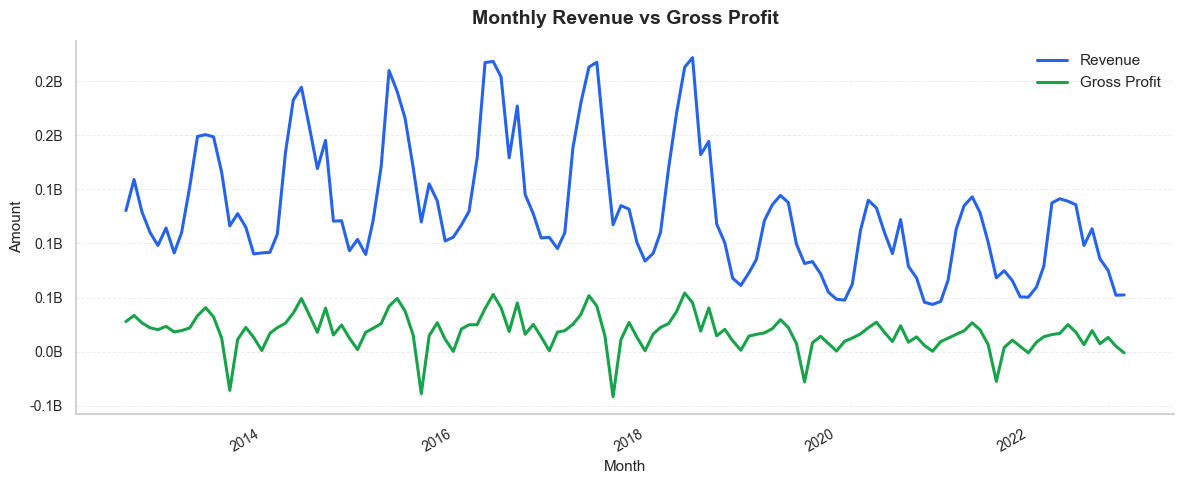

In [252]:
fig, ax1 = plt.subplots(figsize=(12, 5))

sns.lineplot(data=monthly_finance, x="Date", y="Revenue", ax=ax1, color=CHART_COLORS["revenue"], label="Revenue", linewidth=2.2)
sns.lineplot(data=monthly_finance, x="Date", y="Gross_Profit", ax=ax1, color=CHART_COLORS["margin"], label="Gross Profit", linewidth=2.2)
style_axis(ax1, "Monthly Revenue vs Gross Profit", xlabel="Month", ylabel="Amount", y_format="billions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


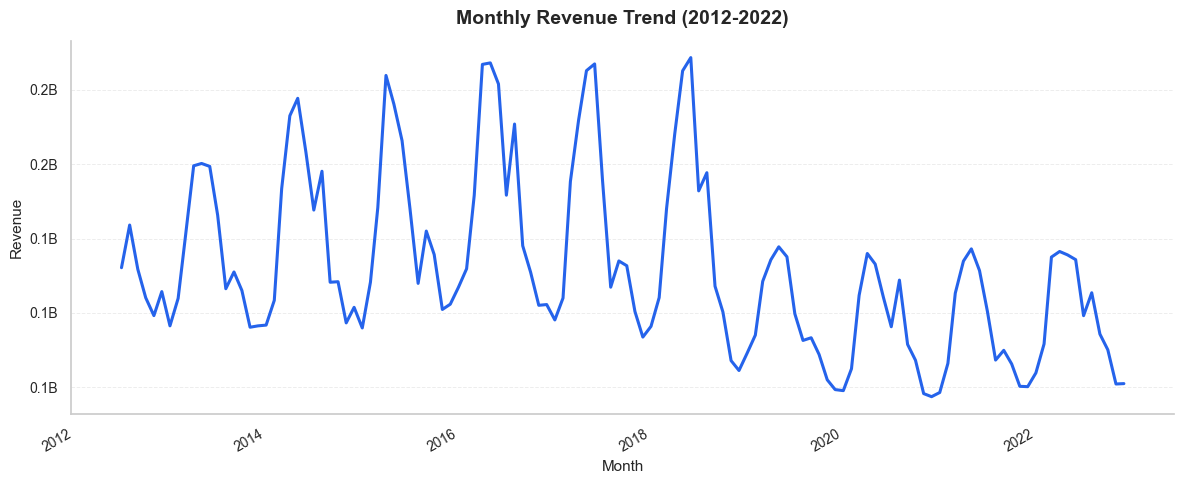

In [253]:
monthly_total = monthly.groupby(["year", "month"])[["Revenue", "COGS"]].sum().reset_index()
monthly_total["date"] = pd.to_datetime(
    monthly_total["year"].astype(str) + "-" + monthly_total["month"].astype(str) + "-01"
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=monthly_total, x="date", y="Revenue", ax=ax, color=CHART_COLORS["revenue"], linewidth=2.2)
style_axis(ax, "Monthly Revenue Trend (2012-2022)", xlabel="Month", ylabel="Revenue", y_format="billions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Insight - revenue trend:** Revenue peaks earlier in the history, with 2016 as the strongest full year, while 2022 revenue is lower than the historical peak. Forecasting should therefore avoid assuming a simple linear upward trend.

**Ch? th?ch chart:** The line is aggregated monthly to reduce daily noise and make long-term movement easier to read. Values are displayed in billions for readability.


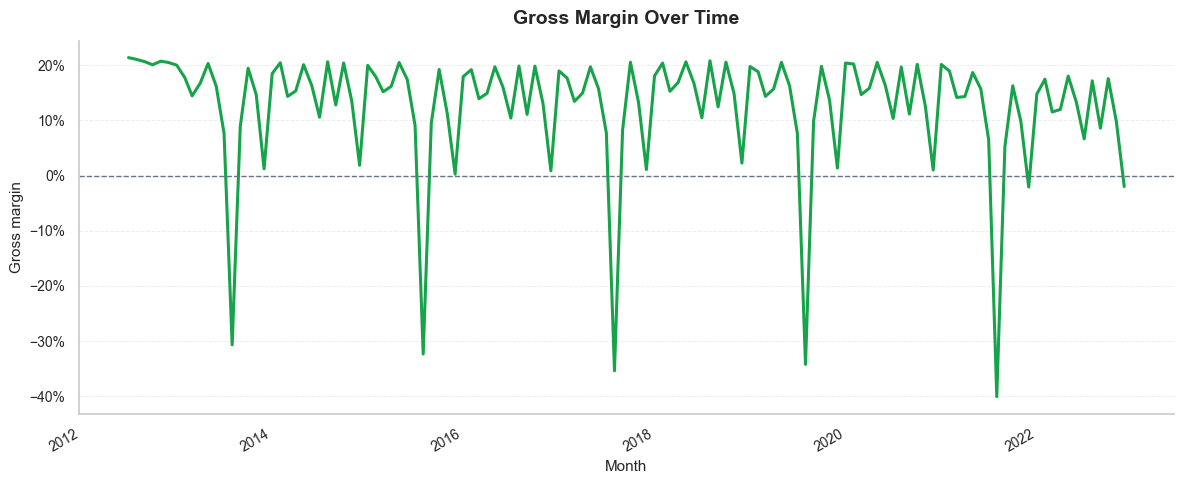

In [254]:
monthly_total["margin"] = (monthly_total["Revenue"] - monthly_total["COGS"]) / monthly_total["Revenue"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=monthly_total, x="date", y="margin", ax=ax, color=CHART_COLORS["margin"], linewidth=2.2)
ax.axhline(0, color=CHART_COLORS["neutral"], linewidth=1, linestyle="--")
style_axis(ax, "Gross Margin Over Time", xlabel="Month", ylabel="Gross margin", y_format="percent")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Insight - margin:** Gross margin is not stable across the full period. Some months are much less profitable, so revenue growth alone can be misleading if COGS rises faster than sales.

**Ch? th?ch chart:** The dashed zero line separates profitable and loss-making monthly periods. Large drops should be checked against promotion periods, returns, product mix, or cost changes.


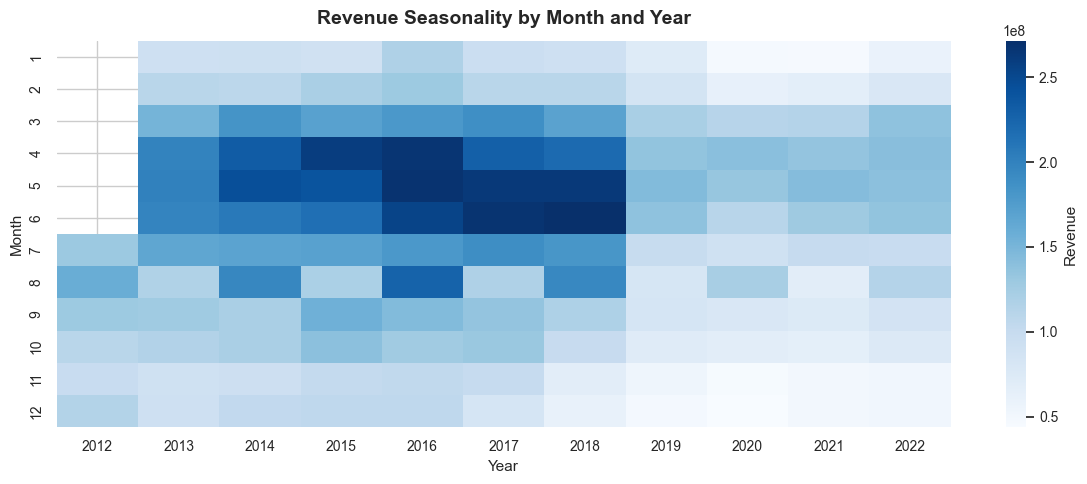

In [255]:
pivot = monthly.pivot(index="month", columns="year", values="Revenue")

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, cmap="Blues", ax=ax, cbar_kws={"label": "Revenue"})
ax.set_title("Revenue Seasonality by Month and Year", pad=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Month")
plt.tight_layout()
plt.show()


**Insight - seasonality:** April to June have the highest average daily revenue across the historical data, with May ranking strongest. Seasonal features should receive meaningful weight in the baseline forecast.

**Ch? th?ch chart:** Darker cells indicate higher monthly revenue. Compare across rows to see recurring high-demand months, and across columns to see whether a year is broadly stronger or weaker.


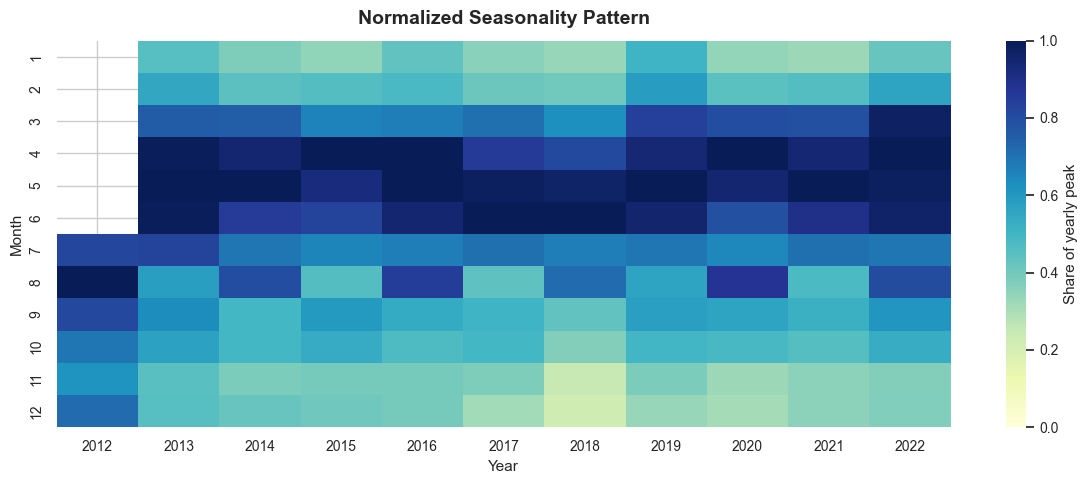

In [256]:
# Normalize each year by its own maximum month to compare seasonality shape independent of yearly scale.
pivot_norm = pivot.div(pivot.max(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_norm, cmap="YlGnBu", ax=ax, vmin=0, vmax=1, cbar_kws={"label": "Share of yearly peak"})
ax.set_title("Normalized Seasonality Pattern", pad=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Month")
plt.tight_layout()
plt.show()


**Insight - normalized seasonality:** Normalization makes each year comparable even when total sales scale changes. Months that stay dark after normalization are recurring seasonal peaks, not just artifacts of strong years.

**Code note:** Use normalized heatmaps when the question is pattern consistency. Use raw heatmaps when the question is absolute revenue contribution.


In [257]:
monthly_rank = train.groupby(["year", "month"])["Revenue"].mean().reset_index()

# Rank months within each year and count recurring top-3 months.
monthly_rank["rank"] = monthly_rank.groupby("year")["Revenue"].rank(ascending=False)

top_months = monthly_rank[monthly_rank["rank"] <= 3]["month"].value_counts().sort_index()
print("Top-3 month frequency by year:")
print(top_months)

print("\nBest months in 2022:")
monthly_rank[monthly_rank["year"] == 2022].sort_values("rank").head(5)


Top-3 month frequency by year:
month
4    10
5    10
6     9
7     1
8     2
9     1
Name: count, dtype: int64

Best months in 2022:


,year,month,Revenue,rank
117,2022,4,4.710184e+06,1.0
119,2022,6,4.527081e+06,2.0
118,2022,5,4.484771e+06,3.0
116,2022,3,4.436708e+06,4.0
121,2022,8,3.662676e+06,5.0


**Insight - forecasting feature:** Ranking months within each year helps identify robust seasonal peaks. This is useful for forecasting because it separates recurring calendar effects from one-off annual scale changes.


## 4. Customer Segmentation with RFM

RFM segments customers by:
- **Recency:** how recently they purchased.
- **Frequency:** how often they purchased.
- **Monetary:** how much revenue they generated.

**Important assumption:** RFM is calculated from `valid_orders` only, meaning delivered orders. This prevents cancelled or unfinished orders from inflating frequency and monetary value.

**Business context:** Champions are the high-recency and high-frequency customers who create the strongest customer value base. Compare both revenue and gross profit contribution before deciding which segment to prioritize.


In [258]:
# Calculate RFM metrics from delivered orders only.
valid_orders["order_date"] = pd.to_datetime(valid_orders["order_date"])
snapshot_date = valid_orders["order_date"].max() + pd.Timedelta(days=1)

rfm = valid_orders.groupby("customer_id").agg({
    "order_date": lambda x: (snapshot_date - x.max()).days,
    "order_id": "count"
}).rename(columns={
    "order_date": "recency",
    "order_id": "frequency"
})

order_items["revenue"] = order_items["quantity"] * order_items["unit_price"]

revenue_per_customer = order_items.merge(
    valid_orders[["order_id", "customer_id"]],
    on="order_id",
    how="inner"
).groupby("customer_id")["revenue"].sum()

rfm = rfm.merge(revenue_per_customer, on="customer_id")
rfm = rfm.rename(columns={"revenue": "monetary"})


In [259]:
print(rfm)

             recency  frequency   monetary
customer_id                               
1               1042          4   98782.44
2                179          2  146787.34
3               3690          2   12001.55
4                917          1   13340.32
5               1376          5   69075.34
...              ...        ...        ...
157554           229          1    6263.81
157555          1292          2   98616.33
157557          2039          1    5670.72
157561           860         19  525608.26
157563           584         18  388567.13

[85115 rows x 3 columns]


In [260]:
rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5])

rfm["RFM_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

In [261]:
#customer segmentation
def segment(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4:
        return "Champions"
    elif row["R_score"] >= 3 and row["F_score"] >= 3:
        return "Loyal"
    elif row["R_score"] <= 2 and row["F_score"] >= 4:
        return "At Risk"
    elif row["F_score"] <= 2:
        return "Low Value"
    else:
        return "Others"

rfm["segment"] = rfm.apply(segment, axis=1)
# check distribution of segments
rfm["segment"].value_counts()
#revenue contribution
rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)

print(rfm[rfm["segment"] == "Champions"].head(20))

             recency  frequency   monetary R_score F_score M_score RFM_score  \
customer_id                                                                    
6                560          9   77295.95       4       4       3       443   
10               240         10  265157.13       5       4       5       545   
22               125          8  162673.29       5       4       4       544   
23               275         14  266779.74       5       5       5       555   
24               554          7  153290.39       4       4       4       444   
32               737         10  277510.17       4       4       5       445   
43               182          9  262984.55       5       4       5       545   
45               581          9  227148.51       4       4       4       444   
46               274         10  350607.90       5       4       5       545   
47                51          6  135401.19       5       4       4       544   
48               202          9  142957.

**Additional Metrics - Customer Value Contribution**

RFM tells us customer behavior, but business value should be checked with both revenue and gross profit. This block measures whether the same customer segments create revenue and profit.


In [262]:
# Act 2 metrics: revenue, gross profit, margin, and Pareto contribution by customer.
# Use delivered orders only so customer value reflects completed purchases.
customer_items = order_items.merge(valid_orders[["order_id", "customer_id"]], on="order_id", how="inner")
customer_items = customer_items.merge(products[["product_id", "category", "cogs"]], on="product_id", how="left")

customer_items["revenue"] = customer_items["quantity"] * customer_items["unit_price"]
customer_items["gross_profit"] = customer_items["revenue"] - customer_items["quantity"] * customer_items["cogs"]

customer_metrics = customer_items.groupby("customer_id").agg(
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    orders=("order_id", "nunique"),
).reset_index()
customer_metrics["margin"] = customer_metrics["gross_profit"] / customer_metrics["revenue"]

customer_metrics = customer_metrics.merge(rfm[["segment"]].reset_index(), on="customer_id", how="left")

segment_value = customer_metrics.groupby("segment").agg(
    customers=("customer_id", "nunique"),
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_margin=("margin", "mean"),
).reset_index()
segment_value["revenue_share"] = segment_value["revenue"] / segment_value["revenue"].sum()
segment_value["profit_share"] = segment_value["gross_profit"] / segment_value["gross_profit"].sum()
segment_value.sort_values("revenue", ascending=False)


,segment,customers,revenue,gross_profit,avg_margin,revenue_share,profit_share
1,Champions,23487,8.272432e+09,1.138086e+09,0.135195,0.630661,0.627848
3,Loyal,17336,2.612448e+09,3.624511e+08,0.135243,0.199164,0.199953
2,Low Value,34046,1.136024e+09,1.564160e+08,0.131863,0.086606,0.086290
0,At Risk,3342,5.724184e+08,8.082669e+07,0.138725,0.043639,0.044590
4,Others,6904,5.237703e+08,7.489790e+07,0.140022,0.039930,0.041319


In [263]:
# Pareto metrics: how concentrated are revenue and profit among top customers?
pareto = customer_metrics.sort_values("revenue", ascending=False).copy()
pareto["customer_rank_pct"] = np.arange(1, len(pareto) + 1) / len(pareto)
pareto["cum_revenue_share"] = pareto["revenue"].cumsum() / pareto["revenue"].sum()
pareto["cum_profit_share"] = pareto["gross_profit"].cumsum() / pareto["gross_profit"].sum()

top_20_cutoff = pareto[pareto["customer_rank_pct"] <= 0.20]
pareto_summary = pd.DataFrame({
    "metric": ["Top 20% Customer Revenue Share", "Top 20% Customer Gross Profit Share"],
    "value": [top_20_cutoff["revenue"].sum() / pareto["revenue"].sum(), top_20_cutoff["gross_profit"].sum() / pareto["gross_profit"].sum()],
})
pareto_summary


,metric,value
0,Top 20% Customer Revenue Share,0.594629
1,Top 20% Customer Gross Profit Share,0.601678


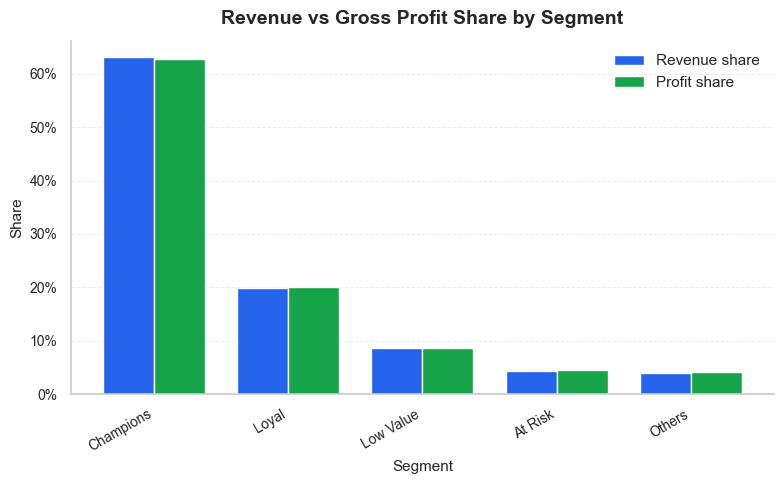

In [264]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = segment_value.sort_values("revenue", ascending=False)

x = np.arange(len(plot_df))
width = 0.38
ax.bar(x - width/2, plot_df["revenue_share"], width, label="Revenue share", color=CHART_COLORS["revenue"])
ax.bar(x + width/2, plot_df["profit_share"], width, label="Profit share", color=CHART_COLORS["margin"])
ax.set_xticks(x)
ax.set_xticklabels(plot_df["segment"], rotation=30, ha="right")
style_axis(ax, "Revenue vs Gross Profit Share by Segment", xlabel="Segment", ylabel="Share", y_format="percent")
ax.legend()
plt.tight_layout()
plt.show()


**Insight - customer value:** Compare `revenue_share` with `profit_share`. If a segment has high revenue share but lower profit share, it is expensive to serve or heavily discounted. If both are high, that segment should be prioritized for retention.


recency: số ngày kể từ ngày mua hàng gần nhất

frequency: số đơn hàng đã mua

monetary: chi tiêu


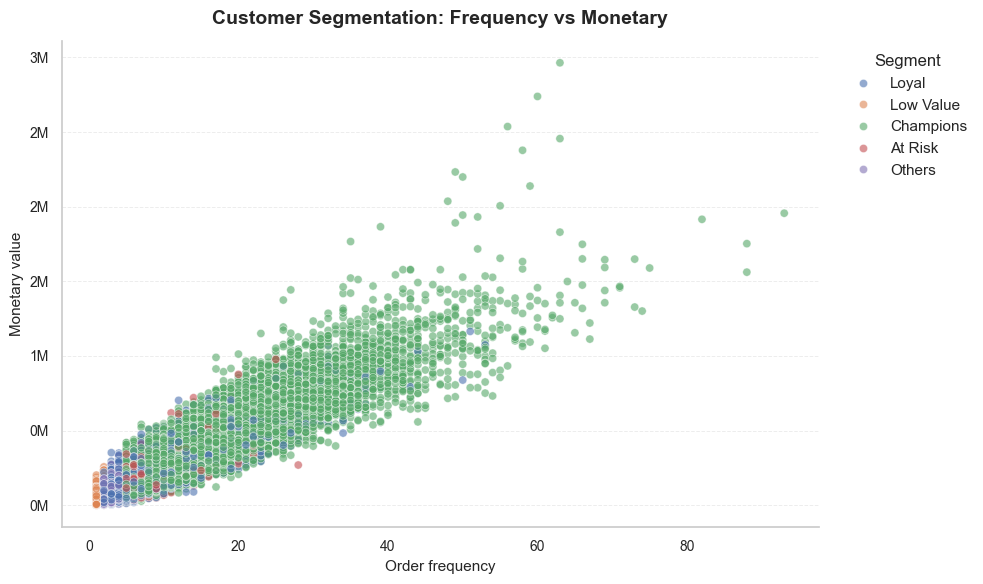

In [265]:
# Visualize segment position by purchase frequency and monetary value.
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=rfm,
    x="frequency",
    y="monetary",
    hue="segment",
    alpha=0.6,
    s=35,
    ax=ax,
)
style_axis(ax, "Customer Segmentation: Frequency vs Monetary", xlabel="Order frequency", ylabel="Monetary value", y_format="millions")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Insight - RFM scatter:** High-frequency customers usually drive higher monetary value, but the spread also reveals customers who buy often without reaching top spend levels. Segment-specific retention and upsell strategies should differ.

**chart:** Each point is one customer. The x-axis shows purchase frequency, while the y-axis shows total monetary contribution.


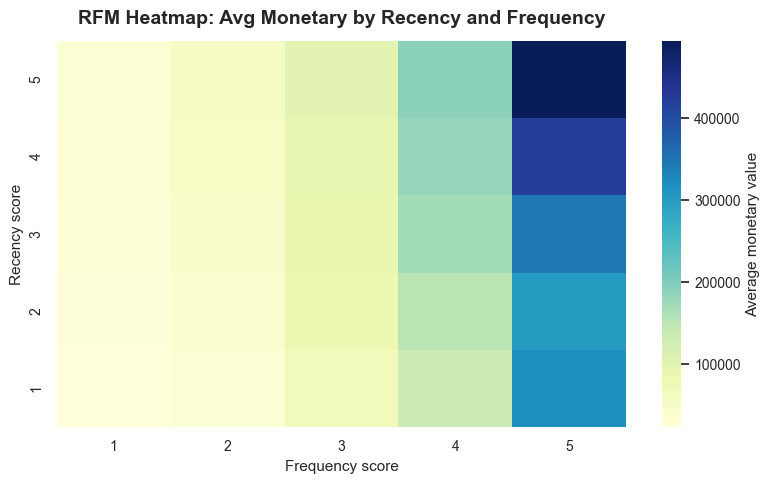

In [266]:
# Heatmap of average monetary value by recency and frequency score.
rf_pivot = rfm.pivot_table(
    index="R_score",
    columns="F_score",
    values="monetary",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(rf_pivot, cmap="YlGnBu", ax=ax, cbar_kws={"label": "Average monetary value"})
ax.set_title("RFM Heatmap: Avg Monetary by Recency and Frequency", pad=12, fontweight="bold")
ax.set_xlabel("Frequency score")
ax.set_ylabel("Recency score")
plt.tight_layout()
plt.show()


**Insight - RFM heatmap:** The most valuable customers are concentrated in the high-recency, high-frequency area. Low recency with high frequency indicates an **At Risk** group worth reactivation because they have proven purchase behavior.

**chart:** Higher `R_score` means more recent purchase. Higher `F_score` means more frequent purchase. Darker cells mean higher average monetary value.


## 5. Cohort Analysis

Cohort analysis tracks customers from their first completed purchase month and measures how many return in later months.

**Important assumption:** Cohorts are built from `valid_orders` only. Cancelled, created, paid, and shipped orders are excluded because they do not prove that a customer completed a purchase.


In [267]:
# Cohort analysis from delivered orders only.
cohort_orders = valid_orders.copy()
cohort_orders["order_month"] = cohort_orders["order_date"].dt.to_period("M")

cohort = cohort_orders.groupby("customer_id")["order_month"].min().reset_index()
cohort.columns = ["customer_id", "cohort_month"]

cohort_orders = cohort_orders.merge(cohort, on="customer_id", how="left")

# Calculate cohort retention.
cohort_orders["cohort_index"] = (
    (cohort_orders["order_month"].dt.year - cohort_orders["cohort_month"].dt.year) * 12
    + (cohort_orders["order_month"].dt.month - cohort_orders["cohort_month"].dt.month)
    + 1
)

cohort_data = cohort_orders.groupby(["cohort_month", "cohort_index"])["customer_id"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="cohort_month", columns="cohort_index", values="customer_id")
print(cohort_pivot.head())


cohort_index     1      2      3      4      5      6      7      8      9    \
cohort_month                                                                   
2012-07       3959.0  458.0  404.0  281.0  293.0  446.0  286.0  315.0  462.0   
2012-08       4262.0  408.0  344.0  345.0  445.0  282.0  332.0  449.0  619.0   
2012-09       3115.0  249.0  232.0  326.0  210.0  223.0  310.0  398.0  400.0   
2012-10       2281.0  158.0  228.0  156.0  199.0  227.0  293.0  284.0  301.0   
2012-11       1981.0  197.0  109.0  146.0  176.0  226.0  214.0  208.0  202.0   

cohort_index    10   ...    117    118    119    120    121    122    123  \
cohort_month         ...                                                    
2012-07       569.0  ...  284.0  271.0  305.0  253.0  184.0  224.0  164.0   
2012-08       546.0  ...  303.0  265.0  300.0  207.0  212.0  187.0  152.0   
2012-09       414.0  ...  181.0  183.0  141.0  147.0  122.0   92.0   81.0   
2012-10       240.0  ...  141.0  104.0  105.0   93.0  

In [268]:
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)
retention.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,...,117,118,119,120,121,122,123,124,125,126
cohort_month,,,,,,,,,,,,,,,,,,,,,
2012-07,1.0,0.115686,0.102046,0.070978,0.074009,0.112655,0.072240,0.079566,0.116696,0.143723,...,0.071735,0.068452,0.077040,0.063905,0.046476,0.056580,0.041425,0.035362,0.028290,0.039656
2012-08,1.0,0.095730,0.080713,0.080948,0.104411,0.066166,0.077898,0.105350,0.145237,0.128109,...,0.071093,0.062177,0.070389,0.048569,0.049742,0.043876,0.035664,0.024167,0.039887,NaN
2012-09,1.0,0.079936,0.074478,0.104655,0.067416,0.071589,0.099518,0.127769,0.128411,0.132905,...,0.058106,0.058748,0.045265,0.047191,0.039165,0.029535,0.026003,0.042697,NaN,NaN
2012-10,1.0,0.069268,0.099956,0.068391,0.087242,0.099518,0.128452,0.124507,0.131960,0.105217,...,0.061815,0.045594,0.046032,0.040772,0.031127,0.024112,0.037703,NaN,NaN,NaN
2012-11,1.0,0.099445,0.055023,0.073700,0.088844,0.114084,0.108026,0.104997,0.101969,0.110045,...,0.036850,0.049470,0.036850,0.033821,0.032307,0.034831,NaN,NaN,NaN,NaN


**Additional Metrics - Repeat Purchase & At-Risk Value**

Cohort retention shows the time pattern. These metrics summarize the customer-level retention problem and quantify how much value is sitting in customers who may churn.


In [269]:
# Act 3 metrics: repeat rate, one-time buyer rate, days since last purchase, and at-risk value.
# Use delivered orders only.
customer_orders = valid_orders.groupby("customer_id").agg(
    first_order=("order_date", "min"),
    last_order=("order_date", "max"),
    order_count=("order_id", "nunique"),
).reset_index()

customer_orders["is_repeat"] = customer_orders["order_count"] > 1
customer_orders["days_since_last_order"] = (valid_orders["order_date"].max() - customer_orders["last_order"]).dt.days

customer_repeat_rate = customer_orders["is_repeat"].mean()
one_time_rate = 1 - customer_repeat_rate

retention_summary = pd.DataFrame({
    "metric": ["Repeat Purchase Rate", "One-time Buyer Rate", "Median Days Since Last Order"],
    "value": [customer_repeat_rate, one_time_rate, customer_orders["days_since_last_order"].median()],
})
retention_summary


,metric,value
0,Repeat Purchase Rate,0.731622
1,One-time Buyer Rate,0.268378
2,Median Days Since Last Order,1142.000000


In [270]:
at_risk_customers = rfm[rfm["segment"] == "At Risk"]

at_risk_value = pd.DataFrame({
    "customers": [at_risk_customers["segment"].count()],
    "monetary_value": [at_risk_customers["monetary"].sum()],
    "avg_monetary": [at_risk_customers["monetary"].mean()],
    "avg_recency": [at_risk_customers["recency"].mean()],
})

at_risk_value


,customers,monetary_value,avg_monetary,avg_recency
0,3342,5.724184e+08,171280.186631,1870.650209


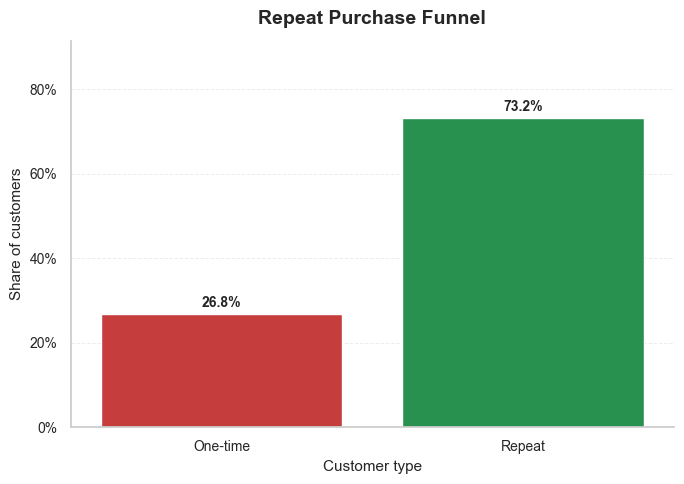

In [271]:
fig, ax = plt.subplots(figsize=(7, 5))
repeat_plot = pd.Series({"One-time": one_time_rate, "Repeat": customer_repeat_rate})
sns.barplot(x=repeat_plot.index, y=repeat_plot.values, palette=[CHART_COLORS["promo"], CHART_COLORS["margin"]], ax=ax)
annotate_bars(ax, fmt="{:.1%}", dy=0.01)
style_axis(ax, "Repeat Purchase Funnel", xlabel="Customer type", ylabel="Share of customers", y_format="percent")
ax.set_ylim(0, max(repeat_plot.values) * 1.25)
plt.tight_layout()
plt.show()


**Insight - Repeat Purchase Funnel:**  
This chart measures the share of customers with one delivered order versus more than one delivered order. Because cancelled and unfinished orders are excluded, the repeat rate now reflects real completed purchase behavior.

A high repeat share means many customers eventually return after their first successful purchase. The one-time buyer group is still important because converting even a small portion of them can create incremental revenue. Use post-purchase engagement, personalized follow-up offers, and targeted reactivation campaigns to move more customers from one-time to repeat behavior.


**Insight - retention metrics:** A high one-time buyer rate means revenue depends on continuous acquisition. The `At Risk` monetary value estimates how much historical customer value could be recovered through targeted reactivation.


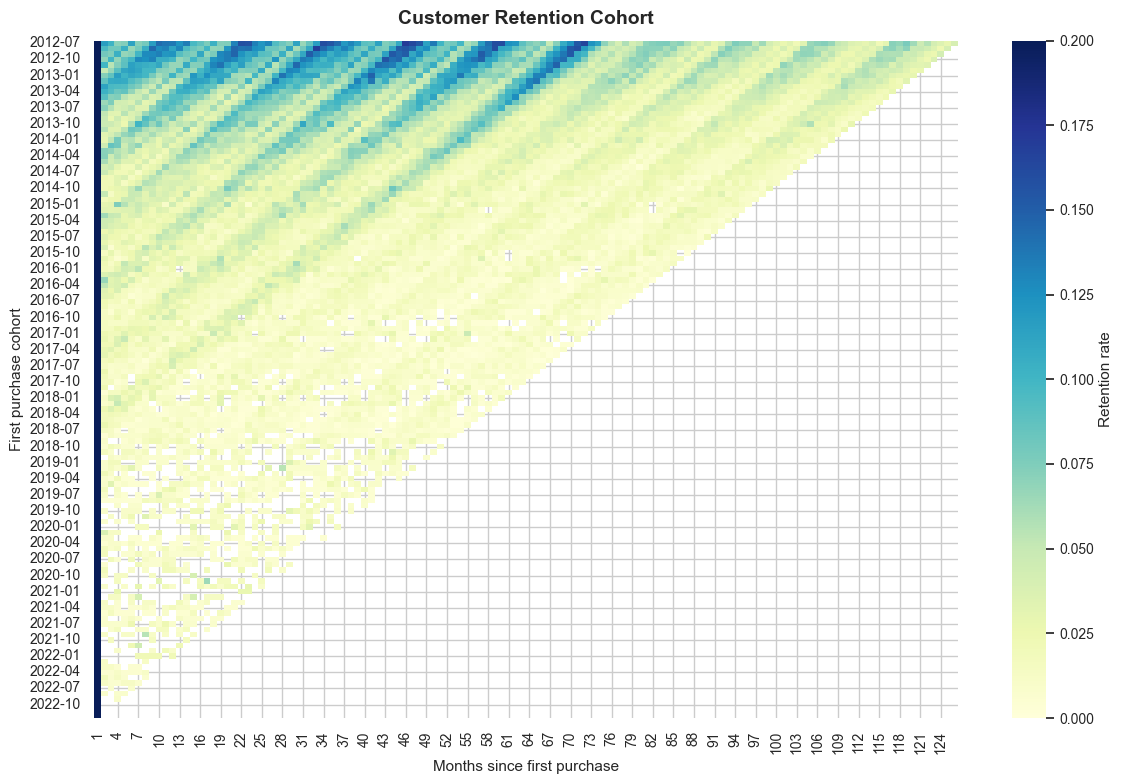

In [272]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    retention,
    cmap="YlGnBu",
    ax=ax,
    vmin=0,
    vmax=0.20,
    cbar_kws={"label": "Retention rate"},
)
ax.set_title("Customer Retention Cohort", pad=12, fontweight="bold")
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("First purchase cohort")
plt.tight_layout()
plt.show()


**Insight - retention:** Cohort analysis reveals a significant retention challenge. Initial customer acquisition appears strong, but retention drops sharply after the first purchase, with only a small proportion of customers returning in subsequent months.

A small group continues to engage over time, forming a loyal core, but this group is limited relative to the full customer base. This suggests long-term revenue is driven by a narrow set of high-value customers rather than broad-based retention.

Retention patterns remain consistently low across cohorts, with no clear evidence of improvement over time. The business therefore appears more dependent on continuous acquisition than on maximizing customer lifetime value.

**chart:** Rows are customer cohorts by first purchase month. Columns are months after first purchase. Darker cells mean stronger retention; a quick fade after column 1 signals weak repeat behavior.


## 6. Promotion Effectiveness

This section checks whether promotions improve customer behavior enough to justify their margin cost.

**Important assumption:** Promo effectiveness is measured on delivered orders only via `valid_orders`. This keeps revenue, repeat behavior, and margin comparisons tied to completed transactions rather than cancelled or still-open orders.


In [273]:
order_items.head(5)

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,revenue
0,1,2400,7,1138.22,0.0,NaN,NaN,7967.54
1,2,609,7,10166.25,0.0,NaN,NaN,71163.75
2,3,396,3,11220.33,0.0,NaN,NaN,33660.99
3,4,635,5,10639.25,0.0,NaN,NaN,53196.25
4,6,1935,1,1597.84,0.0,NaN,NaN,1597.84


In [274]:
# Merge order items with delivered orders to get promo_id and customer behavior.
df = order_items.merge(valid_orders, on="order_id", how="inner")

df["has_promo"] = df["promo_id"].notna()
df[df["promo_id"].notna()][["order_id", "has_promo", "promo_id"]].head()


,order_id,has_promo,promo_id
33097,46253,True,PROMO-0006
33098,46254,True,PROMO-0006
33100,46257,True,PROMO-0006
33101,46257,True,PROMO-0006
33102,46258,True,PROMO-0006


In [275]:
# Analyze how many customers have made purchases with and without promotions.
customer_promo = df.groupby(["customer_id", "has_promo"]).size().unstack(fill_value=0)

(customer_promo > 1).mean()

has_promo
False    0.616860
True     0.482359
dtype: float64

In [276]:
# Analyze revenue by promo usage
df.groupby("has_promo")["revenue"].mean()

has_promo
False    25060.349770
True     19670.441712
Name: revenue, dtype: float64

In [277]:
# Repeat rate by promo exposure among delivered orders.
promo_repeat_rate = (customer_promo > 1).mean()
print(promo_repeat_rate)


has_promo
False    0.616860
True     0.482359
dtype: float64


**Insight - repeat behavior:** Customers exposed to promotions appear less likely to repeat than non-promo customers in this cut of the data. This suggests promotions may be attracting deal-sensitive buyers rather than building durable loyalty.

**Chat:** This is an association, not causal proof. A stronger test would control for channel, product category, order value, acquisition date, and customer tenure.


In [278]:
#promo impact on margin
df = df.merge(products, on="product_id", how="left")

df["cogs_total"] = df["quantity"] * df["cogs"]
df["margin"] = (df["revenue"] - df["cogs_total"]) / df["revenue"]

df.groupby("has_promo")["margin"].mean()

has_promo
False    0.208449
True     0.016109
Name: margin, dtype: float64

**Additional Metrics - Product, Category & Promo Economics**

This block checks whether revenue quality differs by category and whether promotions contribute enough revenue to offset their profit cost.


In [279]:
# Act 4 metrics: category revenue, gross profit, margin, basket size, and promo economics.
df["gross_profit"] = df["revenue"] - df["cogs_total"]
df["discount_rate"] = df["discount_amount"] / (df["revenue"] + df["discount_amount"])
df["discount_rate"] = df["discount_rate"].replace([np.inf, -np.inf], np.nan).fillna(0)

category_metrics = df.groupby("category").agg(
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    orders=("order_id", "nunique"),
    items=("quantity", "sum"),
    avg_discount_rate=("discount_rate", "mean"),
).reset_index()
category_metrics["gross_margin"] = category_metrics["gross_profit"] / category_metrics["revenue"]
category_metrics["revenue_per_order"] = category_metrics["revenue"] / category_metrics["orders"]
category_metrics.sort_values("revenue", ascending=False)


,category,revenue,gross_profit,orders,items,avg_discount_rate,gross_margin,revenue_per_order
3,Streetwear,1.048825e+10,1.390388e+09,311254,1413433,0.041757,0.132566,33696.758842
2,Outdoor,1.988550e+09,3.266764e+08,160000,933785,0.057734,0.164279,12428.436932
0,Casual,3.652635e+08,4.315330e+07,18805,85457,0.043104,0.118143,19423.742670
1,GenZ,2.750270e+08,5.246004e+07,29617,133255,0.042492,0.190745,9286.119249


In [280]:
#share of promo vs non-promo revenue, profit, margin, and discount rate.
promo_metrics = df.groupby("has_promo").agg(
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_revenue=("revenue", "mean"),
    avg_margin=("margin", "mean"),
    orders=("order_id", "nunique"),
    customers=("customer_id", "nunique"),
    avg_discount_rate=("discount_rate", "mean"),
).reset_index()

promo_metrics["gross_margin"] = promo_metrics["gross_profit"] / promo_metrics["revenue"]
promo_metrics["revenue_share"] = promo_metrics["revenue"] / promo_metrics["revenue"].sum()
promo_metrics["profit_share"] = promo_metrics["gross_profit"] / promo_metrics["gross_profit"].sum()
promo_metrics["has_promo"] = promo_metrics["has_promo"].map({False: "No Promo", True: "Promo"})
promo_metrics


,has_promo,revenue,gross_profit,avg_revenue,avg_margin,orders,customers,avg_discount_rate,gross_margin,revenue_share,profit_share
0,No Promo,8.775884e+09,1.752667e+09,25060.349770,0.208449,318708,73686,0.000000,0.199714,0.669042,0.966894
1,Promo,4.341207e+09,6.000999e+07,19670.441712,0.016109,198222,62216,0.123258,0.013823,0.330958,0.033106


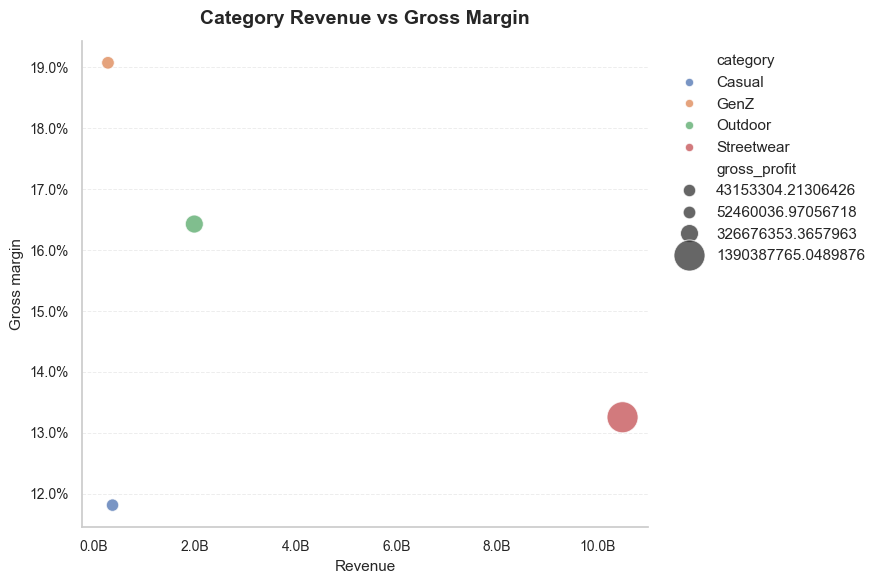

In [281]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=category_metrics,
    x="revenue",
    y="gross_margin",
    size="gross_profit",
    hue="category",
    sizes=(80, 500),
    alpha=0.75,
    ax=ax,
)
style_axis(ax, "Category Revenue vs Gross Margin", xlabel="Revenue", ylabel="Gross margin", y_format="percent")
ax.xaxis.set_major_formatter(FuncFormatter(money_billions))
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


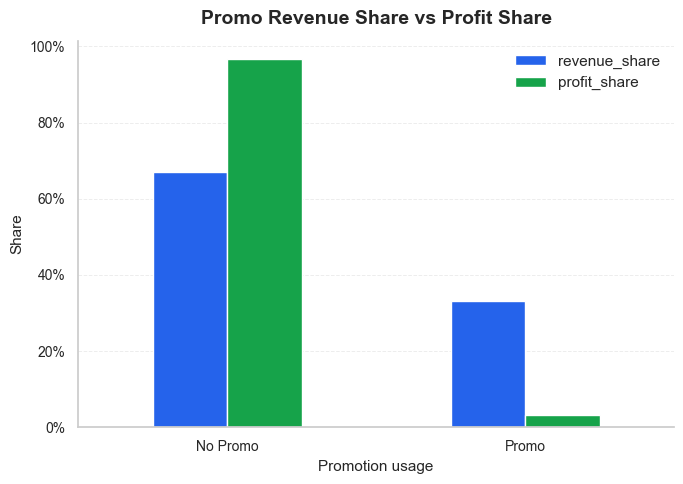

In [282]:
fig, ax = plt.subplots(figsize=(7, 5))
promo_share_plot = promo_metrics.set_index("has_promo")[["revenue_share", "profit_share"]]
promo_share_plot.plot(kind="bar", ax=ax, color=[CHART_COLORS["revenue"], CHART_COLORS["margin"]])
style_axis(ax, "Promo Revenue Share vs Profit Share", xlabel="Promotion usage", ylabel="Share", y_format="percent")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight - product and promo economics:** Categories in the upper-right area are attractive because they combine high revenue with strong margin. Promo should be monitored by both `revenue_share` and `profit_share`; if promo revenue share is much higher than profit share, promotions are diluting profitability.


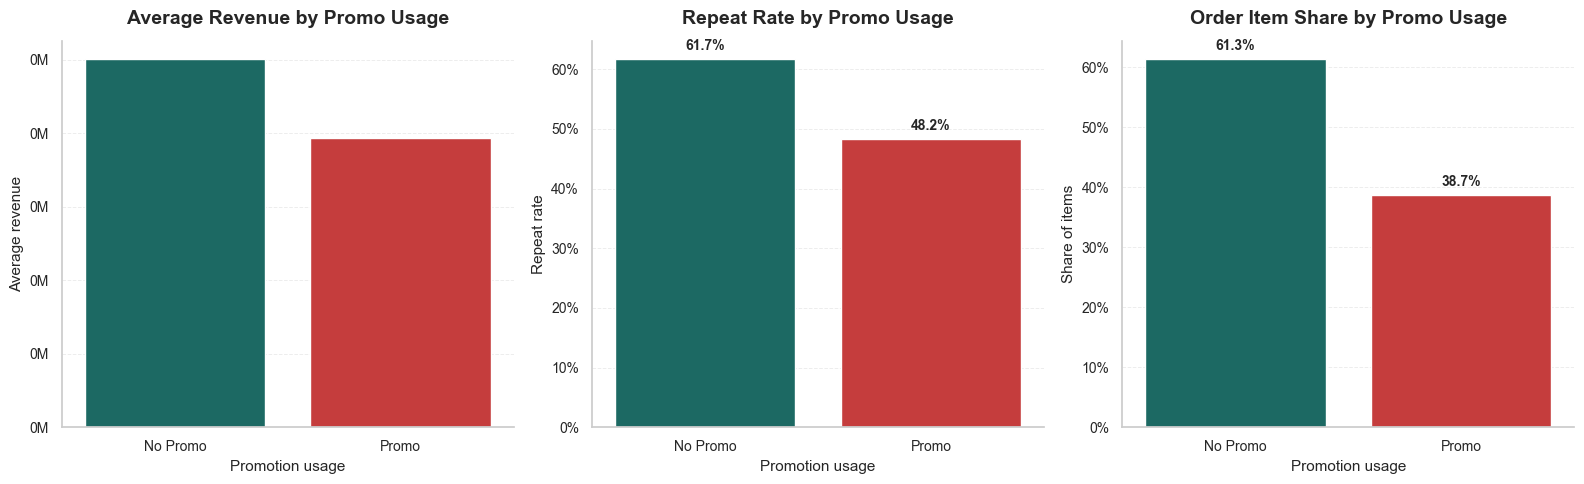

In [283]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Average revenue
revenue_compare = df.groupby("has_promo")["revenue"].mean().rename(index={False: "No Promo", True: "Promo"})
sns.barplot(
    x=revenue_compare.index,
    y=revenue_compare.values,
    palette=[CHART_COLORS["no_promo"], CHART_COLORS["promo"]],
    ax=axes[0],
)
style_axis(axes[0], "Average Revenue by Promo Usage", "Promotion usage", "Average revenue", "millions")

# 2. Repeat rate
repeat_compare = (customer_promo > 1).mean().rename(index={False: "No Promo", True: "Promo"})
sns.barplot(
    x=repeat_compare.index,
    y=repeat_compare.values,
    palette=[CHART_COLORS["no_promo"], CHART_COLORS["promo"]],
    ax=axes[1],
)
annotate_bars(axes[1], fmt="{:.1%}", dy=0.01)
style_axis(axes[1], "Repeat Rate by Promo Usage", "Promotion usage", "Repeat rate", "percent")

# 3. Promo item share
promo_share = df["has_promo"].value_counts(normalize=True).sort_index().rename(index={False: "No Promo", True: "Promo"})
sns.barplot(
    x=promo_share.index,
    y=promo_share.values,
    palette=[CHART_COLORS["no_promo"], CHART_COLORS["promo"]],
    ax=axes[2],
)
annotate_bars(axes[2], fmt="{:.1%}", dy=0.01)
style_axis(axes[2], "Order Item Share by Promo Usage", "Promotion usage", "Share of items", "percent")

plt.tight_layout()
plt.show()


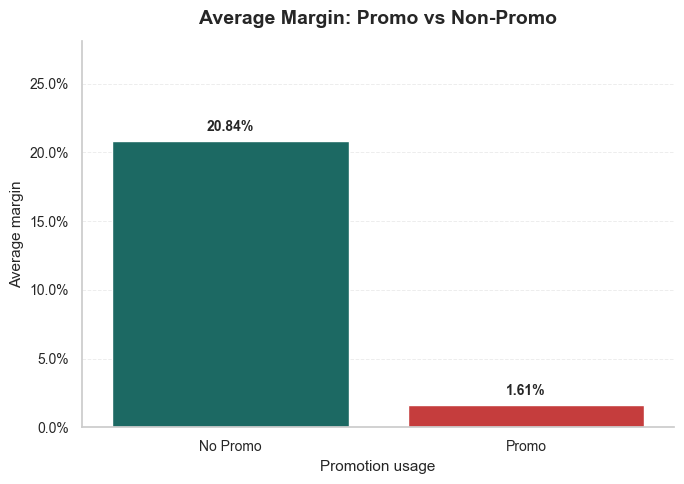

In [284]:
margin_compare = df.groupby("has_promo")["margin"].mean().rename(index={False: "No Promo", True: "Promo"})

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    x=margin_compare.index,
    y=margin_compare.values,
    palette=[CHART_COLORS["no_promo"], CHART_COLORS["promo"]],
    ax=ax,
)
annotate_bars(ax, fmt="{:.2%}", dy=0.005)
style_axis(ax, "Average Margin: Promo vs Non-Promo", xlabel="Promotion usage", ylabel="Average margin", y_format="percent")
ax.set_ylim(0, max(margin_compare.values) * 1.35)
plt.tight_layout()
plt.show()


**Insight - promotion profitability:** Promotions significantly reduce profitability, with average margin dropping from **20.83%** to **1.55%**. Most promotional transactions generate very little profit after COGS.

**Recommendation:** Treat promotions as a targeted retention or acquisition tool, not a blanket revenue lever. Track incremental repeat purchase and incremental gross profit before scaling promo campaigns.


In [285]:
print(train.dtypes)
print(train.describe())
print(train.isna().sum())

Date            datetime64[us]
Revenue                float64
COGS                   float64
year                     int32
month                    int32
Gross_Profit           float64
Gross_Margin           float64
dtype: object
                      Date       Revenue          COGS         year  \
count                 3833  3.833000e+03  3.833000e+03  3833.000000   
mean   2017-10-02 00:00:00  4.286584e+06  3.695134e+06  2017.240543   
min    2012-07-04 00:00:00  2.798139e+05  2.365763e+05  2012.000000   
25%    2015-02-17 00:00:00  2.471089e+06  2.150580e+06  2015.000000   
50%    2017-10-02 00:00:00  3.647304e+06  3.161113e+06  2017.000000   
75%    2020-05-17 00:00:00  5.350877e+06  4.637294e+06  2020.000000   
max    2022-12-31 00:00:00  2.090527e+07  1.653586e+07  2022.000000   
std                    NaN  2.624840e+06  2.219789e+06     3.036754   

             month  Gross_Profit  Gross_Margin  
count  3833.000000  3.833000e+03   3833.000000  
mean      6.665797  5.914495e+0

In [286]:
train.head()


,Date,Revenue,COGS,year,month,Gross_Profit,Gross_Margin
0,2012-07-04,5123547.94,3982991.19,2012,7,1140556.75,0.222611
1,2012-07-05,2751773.45,2150580.23,2012,7,601193.22,0.218475
2,2012-07-06,3054029.42,2517632.84,2012,7,536396.58,0.175636
3,2012-07-07,2667930.94,2108246.62,2012,7,559684.32,0.209782
4,2012-07-08,2360851.90,1808622.79,2012,7,552229.11,0.233911


## 7. Sales Calendar Insights

This section checks day-of-week and month-of-year demand patterns that can be reused as forecasting features.

**Business context:** Wednesday has the highest average daily revenue in the historical data, while Saturday is lowest. Month effects are also visible, with April to June among the strongest periods.


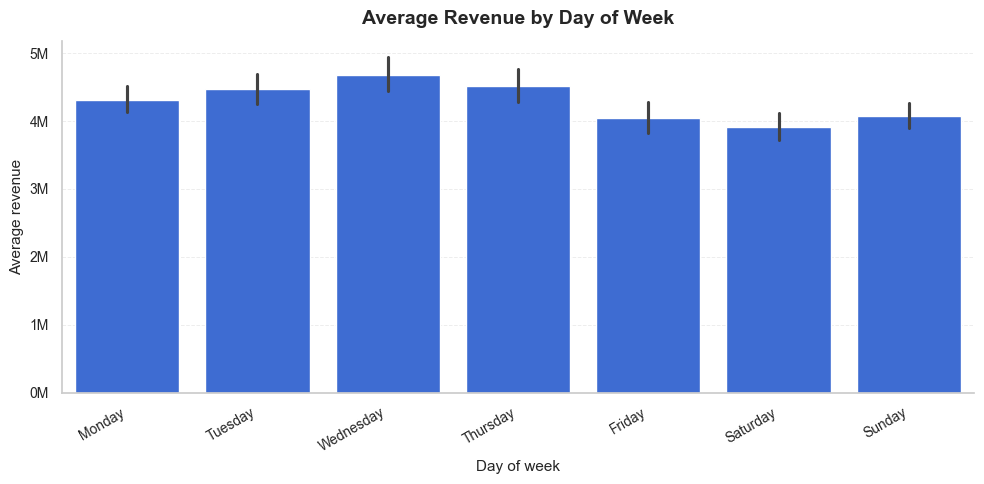

In [287]:
train['day_of_week'] = train['Date'].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x='day_of_week', y='Revenue', data=train, order=weekday_order, color=CHART_COLORS["revenue"], ax=ax)
style_axis(ax, "Average Revenue by Day of Week", xlabel="Day of week", ylabel="Average revenue", y_format="millions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Insight - weekday pattern:** Mid-week demand is stronger than weekend demand, with Wednesday leading average daily revenue. This can improve daily forecast allocation after annual or monthly trend is estimated.

**chart:** Bars show average daily revenue, not total revenue. This avoids bias from some weekdays appearing more often in the calendar.


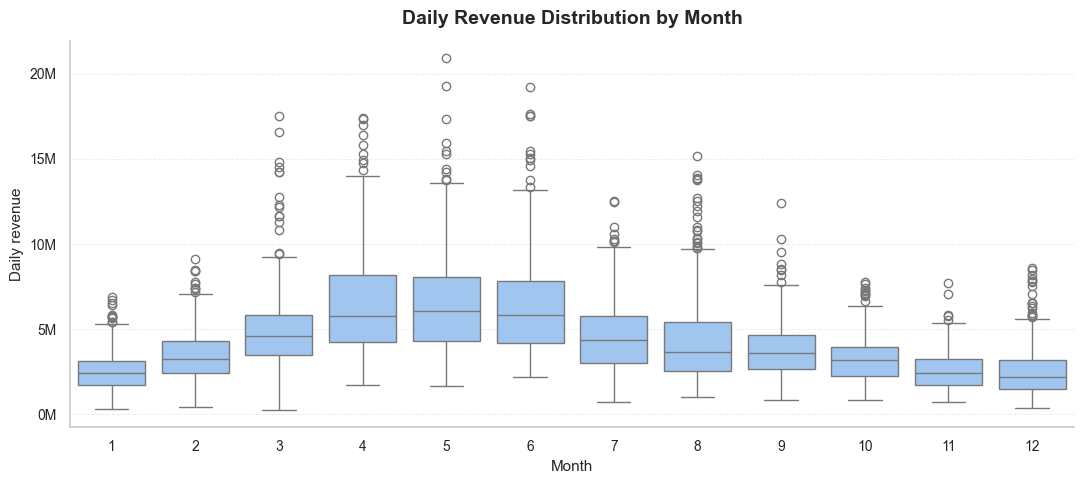

In [288]:
# Monthly performance distribution: median, spread, and outliers by calendar month.
train['month'] = train['Date'].dt.month

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(x='month', y='Revenue', data=train, color="#93C5FD", ax=ax)
style_axis(ax, "Daily Revenue Distribution by Month", xlabel="Month", ylabel="Daily revenue", y_format="millions")
plt.tight_layout()
plt.show()


**Insight - monthly distribution:** Monthly averages identify likely seasonal peaks, while the boxplot shows volatility and outliers. High-variance months need conservative prediction intervals even if their average is attractive.

**chart:** The center line is the median daily revenue. Boxes show the interquartile range, and points beyond whiskers are unusually high or low daily sales.


## Final EDA Metrics Summary

Use this table as the quantitative bridge from EDA to recommendations. It collects the key business health, retention, customer value, and promotion metrics in one place.


In [289]:
# Final EDA summary metrics: key numbers for recommendation slides or report.
final_summary_metrics = pd.DataFrame({
    "metric": [
        "Total Revenue",
        "Total Gross Profit",
        "Overall Gross Margin",
        "Repeat Purchase Rate",
        "One-time Buyer Rate",
        "At-risk Customer Monetary Value",
        "Promo Gross Margin",
        "Non-promo Gross Margin",
    ],
    "value": [
        train["Revenue"].sum(),
        train["Gross_Profit"].sum(),
        train["Gross_Profit"].sum() / train["Revenue"].sum(),
        customer_repeat_rate,
        one_time_rate,
        rfm.loc[rfm["segment"] == "At Risk", "monetary"].sum(),
        df.loc[df["has_promo"], "margin"].mean(),
        df.loc[~df["has_promo"], "margin"].mean(),
    ],
})

final_summary_metrics


,metric,value
0,Total Revenue,1.643048e+10
1,Total Gross Profit,2.267026e+09
2,Overall Gross Margin,1.379769e-01
3,Repeat Purchase Rate,7.316219e-01
4,One-time Buyer Rate,2.683781e-01
5,At-risk Customer Monetary Value,5.724184e+08
6,Promo Gross Margin,1.610866e-02
7,Non-promo Gross Margin,2.084493e-01


In [290]:
# --- YoY growth rate (geometric mean, 2013-2022) ---
# Use full years only and compute annual totals if the notebook was run from this cell.
annual = train.groupby(train['Date'].dt.year)[['Revenue', 'COGS']].sum()
full_years = annual.loc[2013:2022]

yoy_rev = full_years['Revenue'].pct_change().dropna()
yoy_cogs = full_years['COGS'].pct_change().dropna()

growth_rev = (1 + yoy_rev).prod() ** (1 / len(yoy_rev))
growth_cogs = (1 + yoy_cogs).prod() ** (1 / len(yoy_cogs))

print(f'Geometric mean YoY Revenue growth : {growth_rev:.4f}  ({(growth_rev-1)*100:.2f}%/yr)')
print(f'Geometric mean YoY COGS    growth : {growth_cogs:.4f}  ({(growth_cogs-1)*100:.2f}%/yr)')


Geometric mean YoY Revenue growth : 0.9620  (-3.80%/yr)
Geometric mean YoY COGS    growth : 0.9605  (-3.95%/yr)


**Insight - trend input for forecast:** Geometric mean growth is more appropriate than a simple average when growth compounds across years. Because the history contains peak and decline periods, inspect YoY values before trusting a single growth factor.

**Code note:** This cell now creates `annual` directly, so the growth calculation does not depend on a hidden earlier cell state.
